# Standard Random Forest - Kidney Stone Risk Prediction Dataset

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
with open("../data/processed_data.pkl","rb") as f: data = pickle.load(f)
X_train=data["X_train"]; X_test=data["X_test"]
y_train=data["y_train"]; y_test=data["y_test"]
feature_names=data["feature_names"]
print(f"Training: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {feature_names}")


Training: (3200, 23) | Test: (800, 23)
Features: ['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'physical_activity', 'diet', 'water_intake', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level', 'months', 'cluster', 'ckd_pred', 'ckd_stage']


In [3]:
rf = RandomForestClassifier(n_estimators=20, max_depth=4, random_state=42, n_jobs=-1, verbose=1)
print("Training Standard Random Forest...")
_t0 = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
print("Done!")
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = rf.predict(X_train)


Training Standard Random Forest...
Done!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


In [4]:
y_pred = rf.predict(X_test)
extra = ExtraMetrics()
accuracy=accuracy_score(y_test,y_pred); f1=f1_score(y_test,y_pred,zero_division=0)
extra.add(y_test, y_pred, model=rf, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
precision=precision_score(y_test,y_pred,zero_division=0); recall=recall_score(y_test,y_pred,zero_division=0)
print("="*60)
print("STANDARD RANDOM FOREST - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}"); print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}"); print(f"Recall:    {recall:.4f}")
print("="*60)


STANDARD RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.9437
F1-Score:  0.9236
Precision: 0.9855
Recall:    0.8690


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


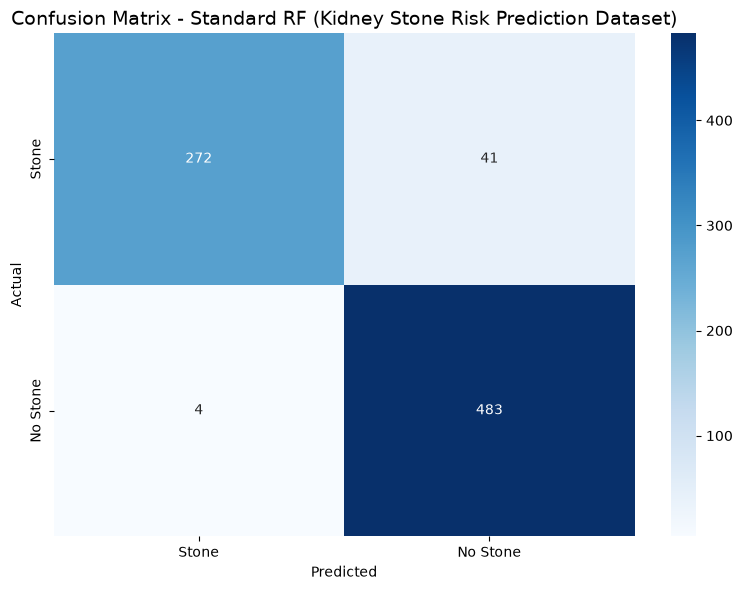


TP: 272, FN: 41, FP: 4, TN: 483


In [5]:
cm=confusion_matrix(y_test,y_pred)
TN,FP,FN,TP=cm[0,0],cm[0,1],cm[1,0],cm[1,1]
custom_cm=np.array([[TP,FN],[FP,TN]])
plt.figure(figsize=(8,6))
sns.heatmap(custom_cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Stone","No Stone"],yticklabels=["Stone","No Stone"])
plt.title("Confusion Matrix - Standard RF (Kidney Stone Risk Prediction Dataset)",fontsize=14)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()
print(f"\nTP: {TP}, FN: {FN}, FP: {FP}, TN: {TN}")


In [6]:
print("Classification Report:")
print(classification_report(y_test,y_pred,target_names=["No Stone","Stone"]))


Classification Report:
              precision    recall  f1-score   support

    No Stone       0.92      0.99      0.96       487
       Stone       0.99      0.87      0.92       313

    accuracy                           0.94       800
   macro avg       0.95      0.93      0.94       800
weighted avg       0.95      0.94      0.94       800



Feature Importances:
              feature  importance
7      oxalate_levels    0.285681
5               c3_c4    0.140370
2                 bun    0.126465
3       serum_calcium    0.093721
8            urine_ph    0.086260
0    serum_creatinine    0.077727
4                 ana    0.077314
6           hematuria    0.072582
12       water_intake    0.027877
20            cluster    0.005482
9      blood_pressure    0.002260
1                 gfr    0.001913
22          ckd_stage    0.000766
18       stress_level    0.000449
11               diet    0.000390
15   painkiller_usage    0.000212
16     family_history    0.000195
19             months    0.000111
17     weight_changes    0.000072
13            smoking    0.000066
10  physical_activity    0.000051
14            alcohol    0.000037
21           ckd_pred    0.000000


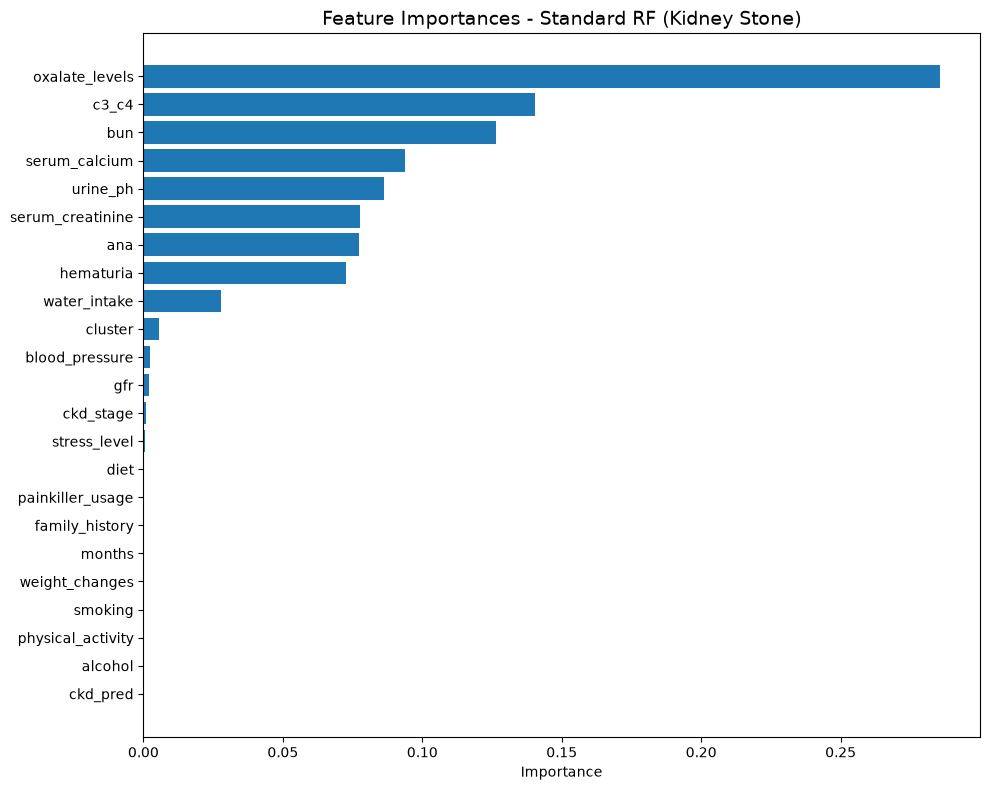

In [7]:
feat_df = pd.DataFrame({"feature":feature_names,"importance":rf.feature_importances_}).sort_values("importance",ascending=False)
print("Feature Importances:"); print(feat_df)
plt.figure(figsize=(10,8))
plt.barh(range(len(feat_df)),feat_df["importance"])
plt.yticks(range(len(feat_df)),feat_df["feature"])
plt.xlabel("Importance"); plt.title("Feature Importances - Standard RF (Kidney Stone)",fontsize=14)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()


In [8]:
os.makedirs("output",exist_ok=True)
pd.DataFrame({**{_k: [_v] for _k, _v in extra.means().items()}, "model":["Standard_RF"],"accuracy":[accuracy],"f1_score":[f1],"precision":[precision],"recall":[recall]}).to_csv("output/baseline_results.csv",index=False)
with open("output/std_rf_report.json","w") as f: json.dump({"model_type":"Standard Random Forest","dataset":"Kidney Stone Risk Prediction Dataset","parameters":{"n_estimators":20,"max_depth":4},"metrics":{**extra.means(), "accuracy":float(accuracy),"f1_score":float(f1),"precision":float(precision),"recall":float(recall)},"confusion_matrix":custom_cm.tolist()},f,indent=4)
print("Baseline saved to output/")

# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model
export_model(rf, 'output/model/std_rf_model.pkl')


print("Added metrics:")
print(extra.describe())

Baseline saved to output/


Model successfully exported to output/model/std_rf_model.pkl
Added metrics:
  Train Acc:      0.9503 ± 0.0000
  Balanced Acc:   0.9304 ± 0.0000
  AUROC:          0.9978 ± 0.0000
  Train Time (s): 0.0604 ± 0.0000


In [9]:
print("\n"+"="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Standard Random Forest | Dataset: Kidney Stone Risk Prediction Dataset")
print(f"Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Accuracy: {accuracy:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
print("="*60)



BASELINE MODEL SUMMARY
Model: Standard Random Forest | Dataset: Kidney Stone Risk Prediction Dataset
Training: 3,200 | Test: 800
Accuracy: 0.9437 | F1: 0.9236 | Precision: 0.9855 | Recall: 0.8690
